In [ ]:
!git clone https://github.com/jasonfghx/GNN.git


Cloning into 'GNN'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 83 (delta 2), reused 0 (delta 0), pack-reused 74 (from 1)
Receiving objects: 100% (83/83), 74.32 MiB | 11.18 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [ ]:
!pip install rdkit torch torch-geometric
!pip install "numpy<2"

In [ ]:
!pip install xgboost==1.7.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 4.4 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.1
    Uninstalling xgboost-3.1.1:
      Successfully uninstalled xgboost-3.1.1


In [ ]:
# 這是DENV inhibitors RdRp_登革熱
from rdkit import Chem
from sklearn.metrics import matthews_corrcoef
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.QED import qed
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import re
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import shap
data=pd.read_csv('/content/GNN/資料集.csv')
data=data.iloc[1:,:]

data=data.reset_index()
data=data[~data['Unnamed: 2'].isnull()]
data=data[~data['Unnamed: 1'].isnull()]
data=data.iloc[:-1,:]
data['Unnamed: 2']=data['Unnamed: 2'].astype("float")
temp=pd.DataFrame({"DENV inhibitors RdRp_登革熱病毒抑制物_3738":[''],'Unnamed: 1':['C1=CC(=C(C=C1OC2=C(C=C(C=C2I)CC(=O)O)I)I)O'],'Unnamed: 2':[4.09]})
data=pd.concat([data,temp])
data=data[data['Unnamed: 2']<1000000]
desc_names = [
    'MolWt', 'HeavyAtomCount', 'NumAtoms', 'NumRings', 'NumAromaticRings', 'FractionCSP3',
    'MolLogP', 'TPSA', 'LabuteASA',
    'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds',
    'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Chi0v', 'Chi1v',
    'PEOE_VSA1', 'PEOE_VSA9', 'EState_VSA3'
]
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None]*len(desc_names)
    values = []
    for desc_name in desc_names:
        if desc_name == 'NumAtoms':
            # 用 Mol 物件的 GetNumAtoms 方法來計算
          values.append(mol.GetNumAtoms())
        elif desc_name == 'NumRings':
            # 使用 mol.GetRingInfo().NumRings() 來計算環數
          values.append(len(mol.GetRingInfo().AtomRings()))
        else:
          func = getattr(Descriptors, desc_name)
          values.append(func(mol))
    return values

desc_values = data['Unnamed: 1'].apply(calc_descriptors)
desc_df = pd.DataFrame(desc_values.tolist(), columns=desc_names)
desc_df=desc_df.reset_index(drop=True,inplace=False)
data=data.reset_index(drop=True,inplace=False)
desc_df['Standard']=data['Unnamed: 2']
desc_df['Standard1']=desc_df['Standard'].apply(lambda x:0 if x>=10000 else 1)
# x>=10000 為0
desc_df1 = desc_df.drop(columns=['Standard'])

X=desc_df1[['MolWt', 'HeavyAtomCount', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'FractionCSP3', 'MolLogP', 'TPSA', 'LabuteASA', 'NumHAcceptors',
       'NumHDonors', 'NumRotatableBonds', 'BalabanJ', 'BertzCT',
       'HallKierAlpha', 'Chi0v', 'Chi1v', 'PEOE_VSA1', 'PEOE_VSA9',
       'EState_VSA3']]

y=desc_df1['Standard1']
print("total number:", X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)


total number: 3554


In [ ]:
desc_df1.iloc[3553,:-1]


,3553
MolWt,621.934000
HeavyAtomCount,21.000000
NumAtoms,21.000000
NumRings,2.000000
NumAromaticRings,2.000000
FractionCSP3,0.071429
MolLogP,4.625400
TPSA,66.760000
LabuteASA,161.867431
NumHAcceptors,3.000000


LogisticRegression
Accuracy: 0.6497890295358649
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       373
           1       0.62      0.67      0.64       338

    accuracy                           0.65       711
   macro avg       0.65      0.65      0.65       711
weighted avg       0.65      0.65      0.65       711



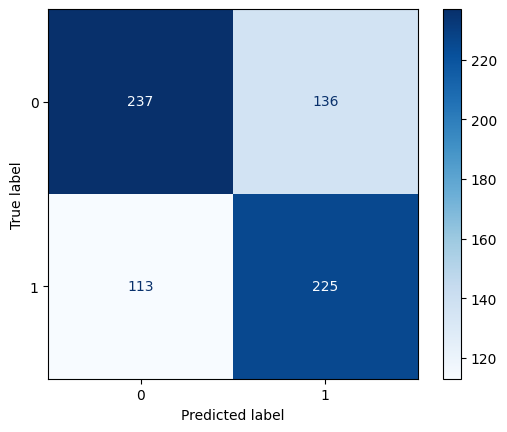

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('LogisticRegression')
print("Accuracy:", accuracy_score(y_test, y_pred))
BA_l=accuracy_score(y_test, y_pred)
mcc_l=matthews_corrcoef(y_test, y_pred)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
model.predict(desc_df1.iloc[3553:,:-1])

array([0])

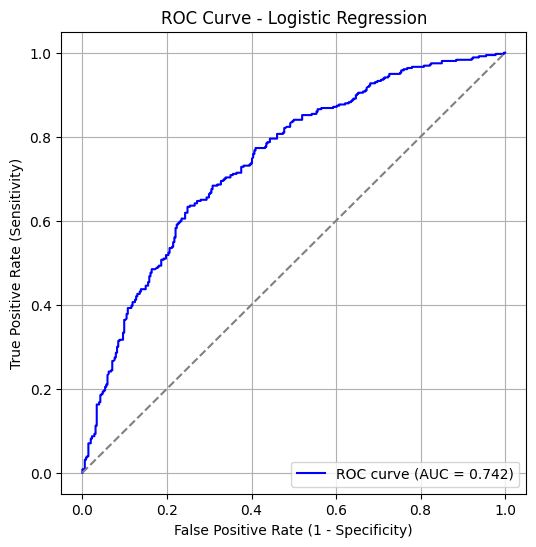

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]

# 計算 ROC 曲線的數據
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 計算 AUC 值
auc = roc_auc_score(y_test, y_prob)
auc_l = roc_auc_score(y_test, y_prob)

# 畫 ROC 曲線
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 參考線（隨機猜測）
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
clf = SVC(kernel='linear', probability=True,)
clf.fit(X_train.iloc[:300,:], y_train.iloc[:300])

# 預測與評估
y_pred = clf.predict(X_test)


In [ ]:
model.predict(desc_df1.iloc[3553:,:-1])

array([0])

In [ ]:
print('SVM')
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
BA_s=accuracy_score(y_test, y_pred)
mcc_s=matthews_corrcoef(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

SVM
Accuracy: 0.6497890295358649
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       373
           1       0.62      0.67      0.64       338

    accuracy                           0.65       711
   macro avg       0.65      0.65      0.65       711
weighted avg       0.65      0.65      0.65       711



NameError: name 'clf' is not defined

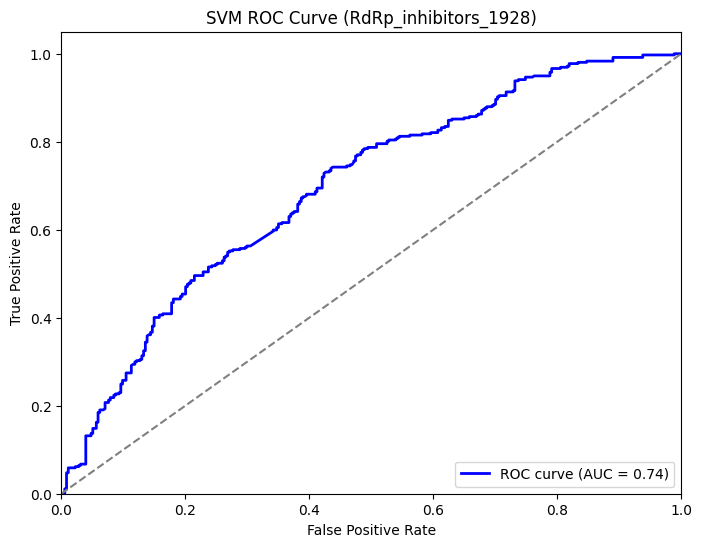

In [ ]:
y_pred_prob = clf.predict_proba(X_test)[:, 1]  # Get the probabilities for the positive class
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_prob)
auc_s = roc_auc_score(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve (RdRp_inhibitors_1928)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
y_score = clf.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# 5. 畫圖
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc="lower right")
plt.show()

RandomForestClassifier
Accuracy: 0.759493670886076
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       373
           1       0.75      0.74      0.75       338

    accuracy                           0.76       711
   macro avg       0.76      0.76      0.76       711
weighted avg       0.76      0.76      0.76       711



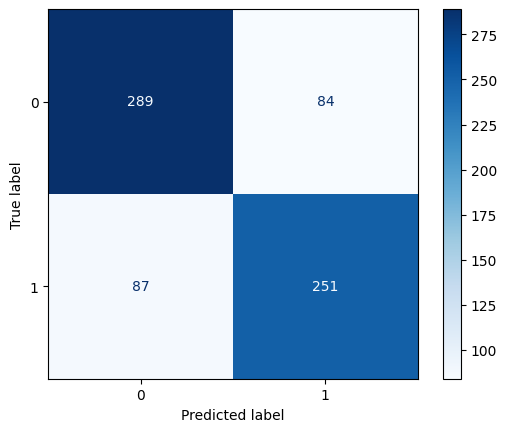

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,      # 樹的數量
    max_depth=None,        # 樹的最大深度（None 代表不限制）
    random_state=42
)

# 4. 訓練模型
rf.fit(X_train, y_train)

# 5. 進行預測
y_pred = rf.predict(X_test)
print('RandomForestClassifier')
print("Accuracy:", accuracy_score(y_test, y_pred))
BA_rf=accuracy_score(y_test, y_pred)
mcc_rf=matthews_corrcoef(y_test, y_pred)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
rf.predict(desc_df1.iloc[3553:,:-1])

array([1])

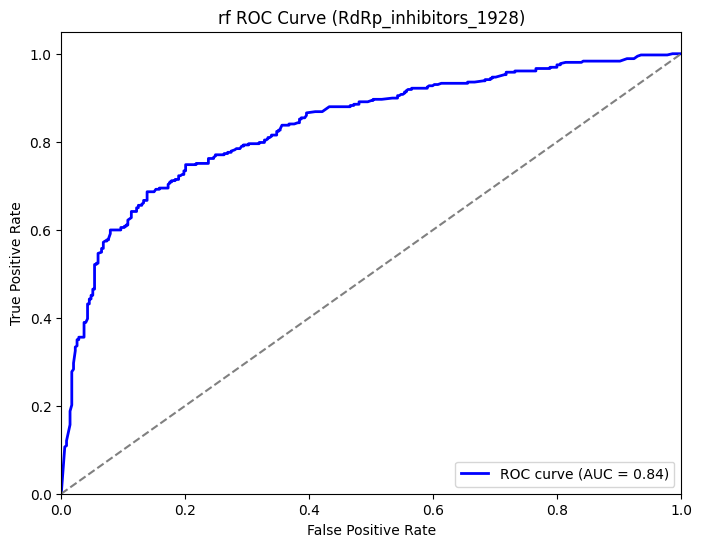

In [ ]:
from sklearn.metrics import roc_curve, auc
y_pred_prob = rf.predict_proba(X_test)[:, 1]  # Get the probabilities for the positive class
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

auc_rf = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('rf ROC Curve (RdRp_inhibitors_1928)')
plt.legend(loc='lower right')
plt.show()

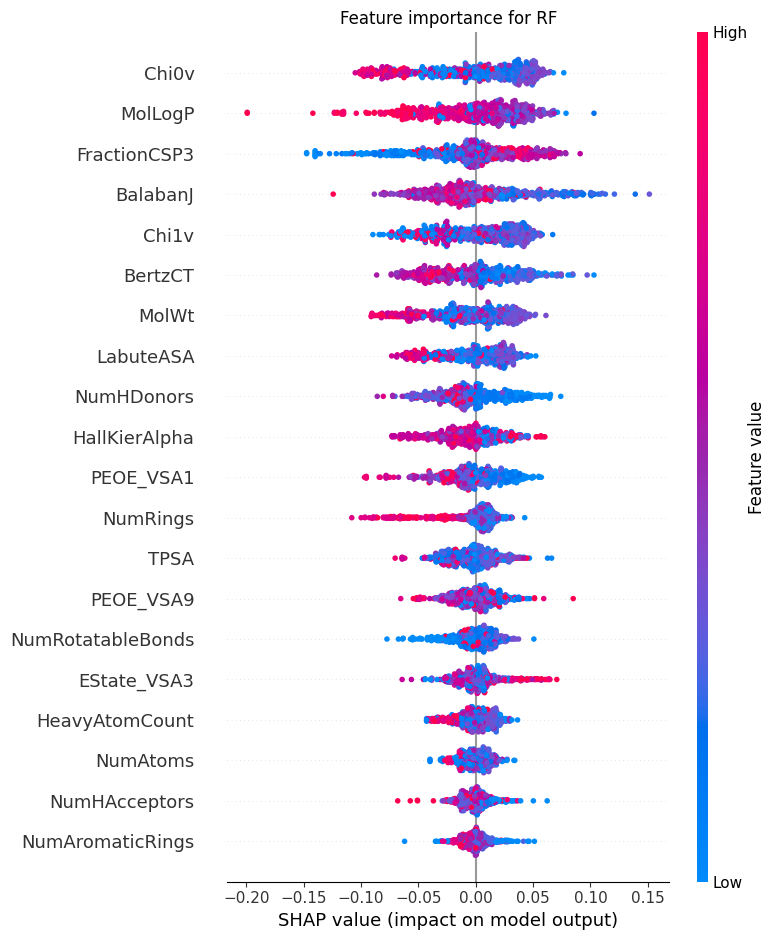

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)
plt.title("Feature importance for RF")
shap.summary_plot(shap_values[:,:,0], X_test)

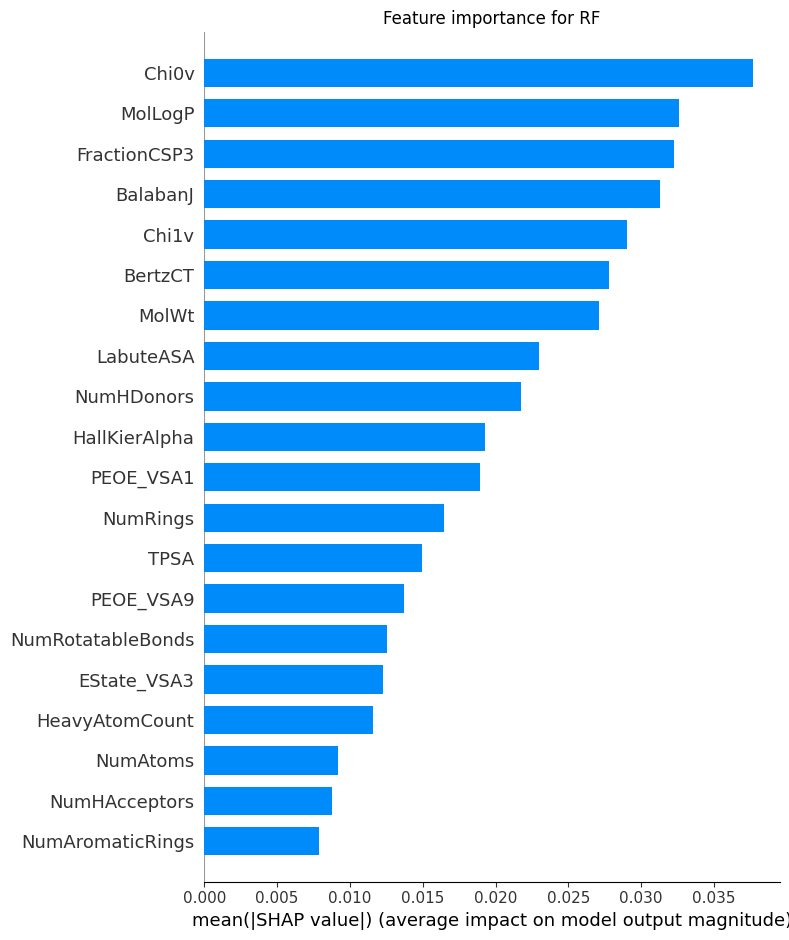

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)
plt.title("Feature importance for RF")
shap.summary_plot(shap_values[:,:,0], X_test,plot_type="bar")

In [ ]:
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
xgb_clf = XGBClassifier(
    n_estimators=1000,
    max_depth=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)
print('XGBOOST')
print("Accuracy:", accuracy_score(y_test, y_pred))
BA_XGB=accuracy_score(y_test, y_pred)
mcc_XGB=matthews_corrcoef(y_test, y_pred)
print(classification_report(y_test, y_pred))


XGBOOST
Accuracy: 0.7665260196905767
              precision    recall  f1-score   support

           0       0.79      0.76      0.77       373
           1       0.75      0.77      0.76       338

    accuracy                           0.77       711
   macro avg       0.77      0.77      0.77       711
weighted avg       0.77      0.77      0.77       711



In [ ]:
xgb_clf.predict(desc_df1.iloc[3553:,:-1])

array([1])

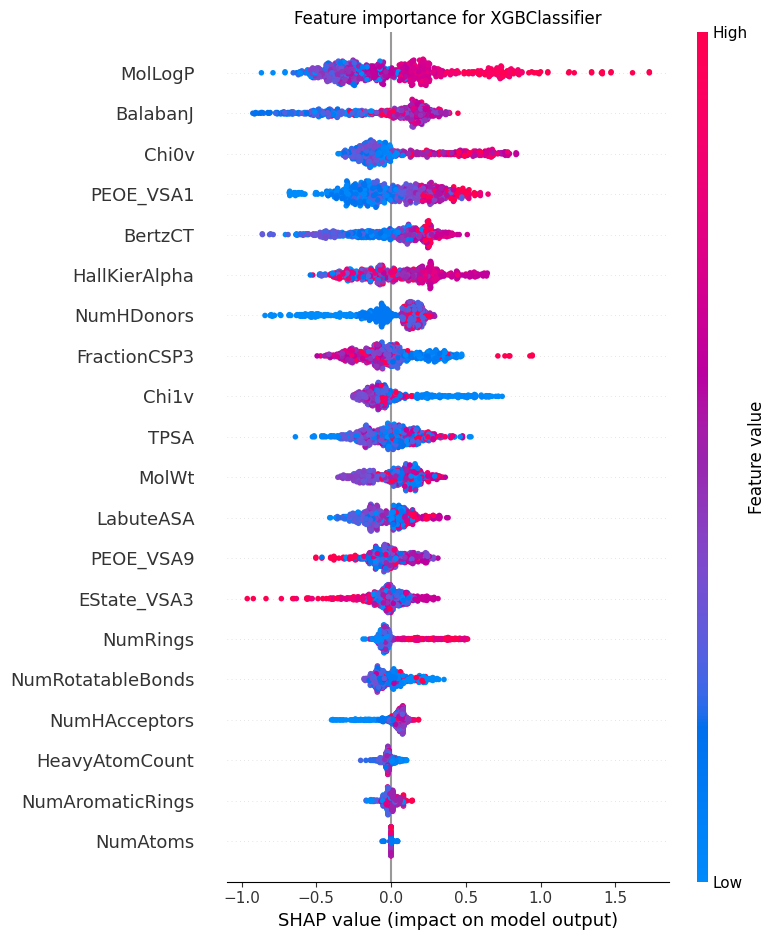

In [ ]:
explainer = shap.TreeExplainer(xgb_clf)

shap_values = explainer.shap_values(X_test)
plt.title("Feature importance for XGBClassifier")
shap.summary_plot(shap_values, X_test)

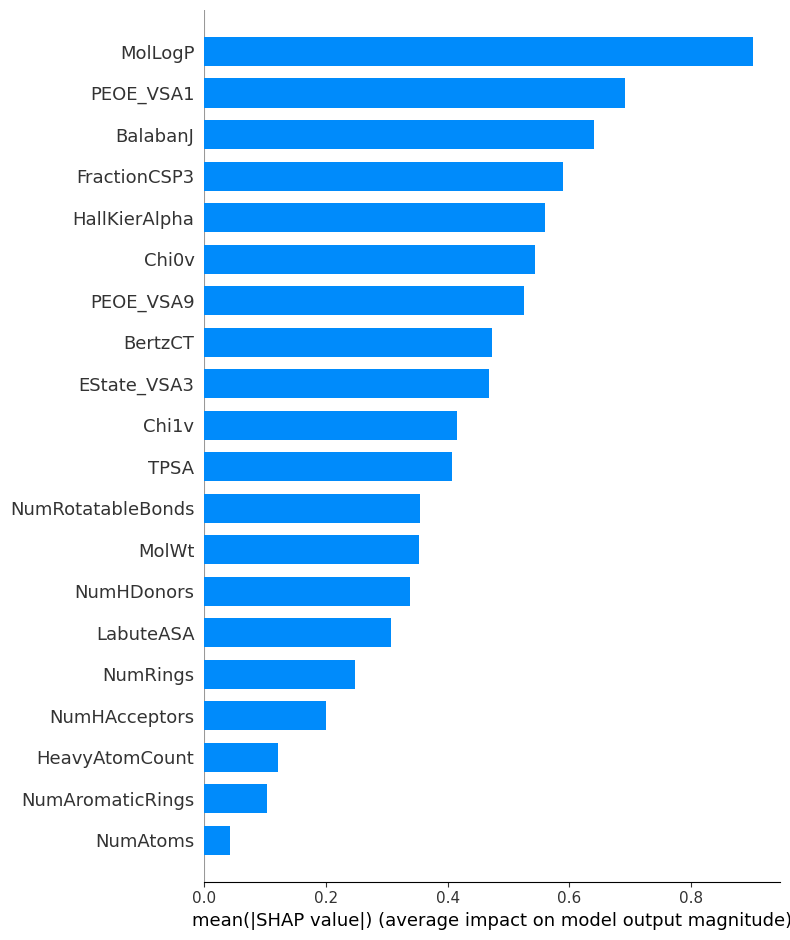

In [ ]:
explainer = shap.TreeExplainer(xgb_clf)

shap_values = explainer.shap_values(X_test)
# plt.title("Feature importance for RF")
shap.summary_plot(shap_values, X_test,plot_type="bar")

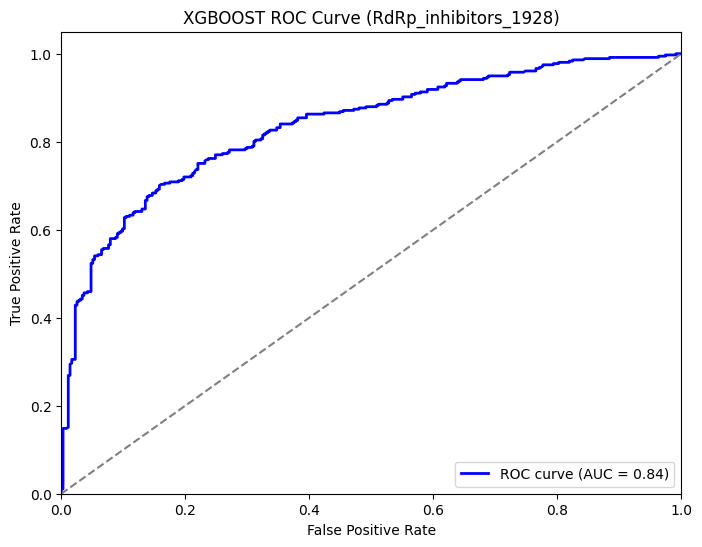

In [ ]:
y_pred_prob = xgb_clf.predict_proba(X_test)[:, 1]  # Get the probabilities for the positive class
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
roc_auc_xgb = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBOOST ROC Curve (RdRp_inhibitors_1928)')
plt.legend(loc='lower right')
plt.show()

GradientBoosting
Accuracy: 0.7327707454289732
              precision    recall  f1-score   support

           0       0.75      0.74      0.74       373
           1       0.72      0.73      0.72       338

    accuracy                           0.73       711
   macro avg       0.73      0.73      0.73       711
weighted avg       0.73      0.73      0.73       711



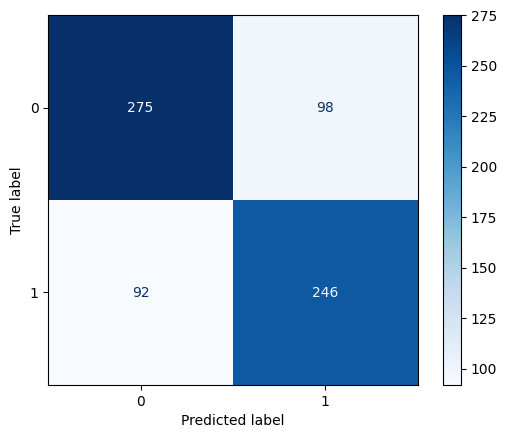

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.5,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
print('GradientBoosting')
print("Accuracy:", accuracy_score(y_test, y_pred))
BA_G=accuracy_score(y_test, y_pred)
mcc_G=matthews_corrcoef(y_test, y_pred)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=gb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=gb.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
gb.predict(desc_df1.iloc[3553:,:-1])

array([1])

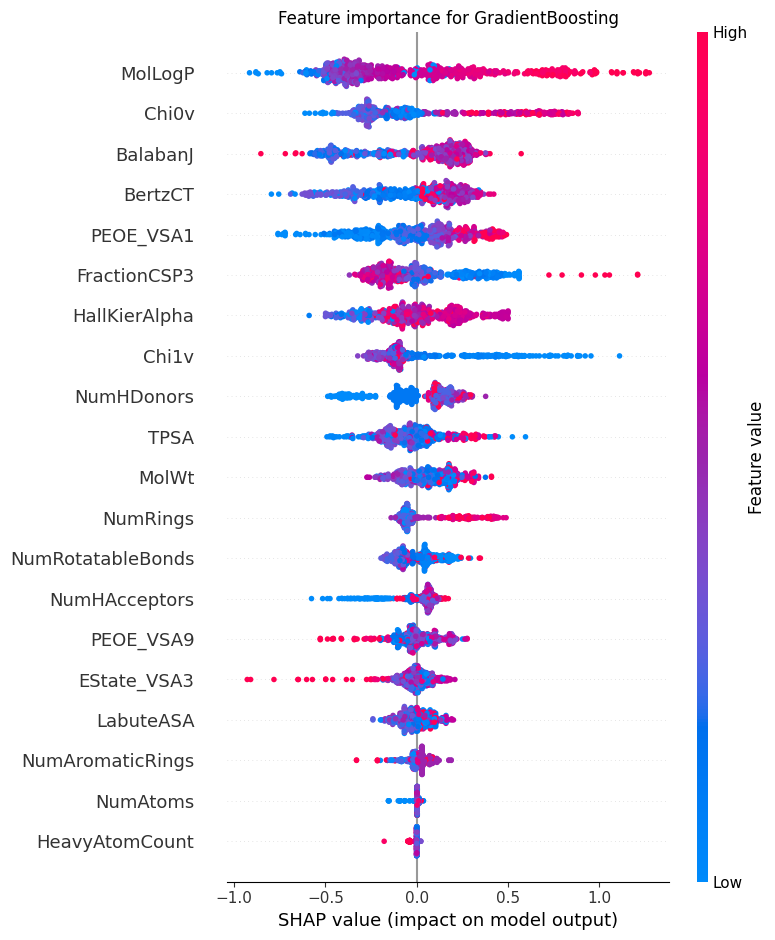

In [ ]:
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

plt.title("Feature importance for GradientBoosting")
shap.summary_plot(shap_values, X_test)

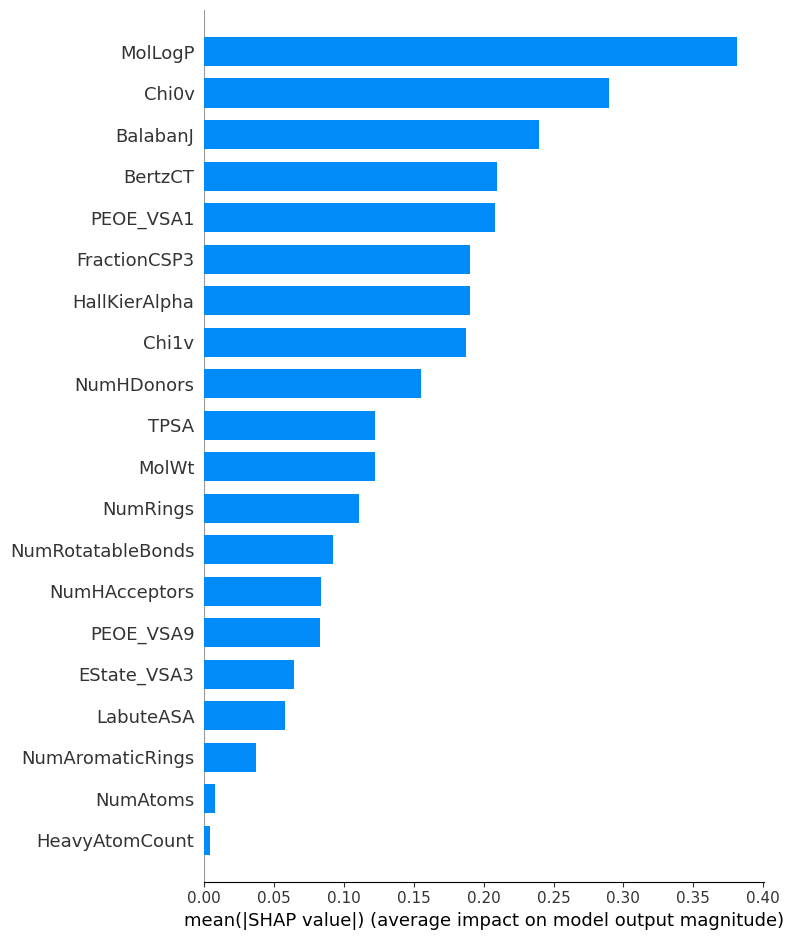

In [ ]:
explainer = shap.TreeExplainer(gb)

shap_values = explainer.shap_values(X_test)
# plt.title("Feature importance for RF")
shap.summary_plot(shap_values, X_test,plot_type="bar")

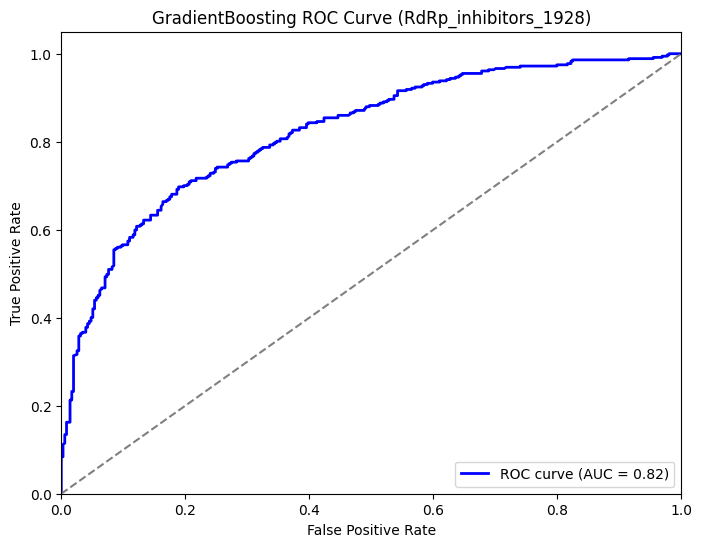

In [ ]:
y_pred_prob = gb.predict_proba(X_test)[:, 1]  # Get the probabilities for the positive class
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GradientBoosting ROC Curve (RdRp_inhibitors_1928)')
plt.legend(loc='lower right')
plt.show()

knn
Accuracy: 0.6385372714486639
              precision    recall  f1-score   support

           0       0.64      0.63      0.63       354
           1       0.64      0.65      0.64       357

    accuracy                           0.64       711
   macro avg       0.64      0.64      0.64       711
weighted avg       0.64      0.64      0.64       711



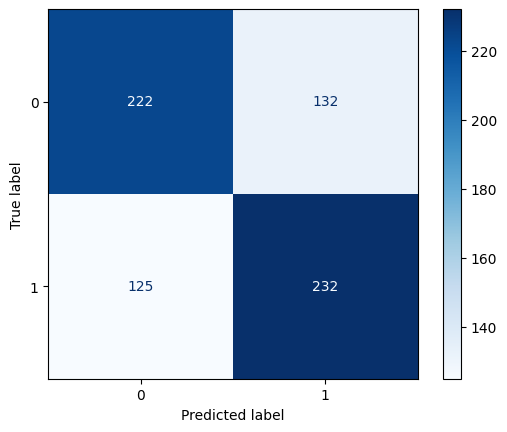

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=50,    # K 值，鄰居數量
    weights='uniform', # 'uniform'：等權重, 'distance'：依距離加權
    metric='minkowski' # 距離度量，預設是歐氏距離
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print('knn')
print("Accuracy:", accuracy_score(y_test, y_pred))
BA_k=accuracy_score(y_test, y_pred)
mcc_k=matthews_corrcoef(y_test, y_pred)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

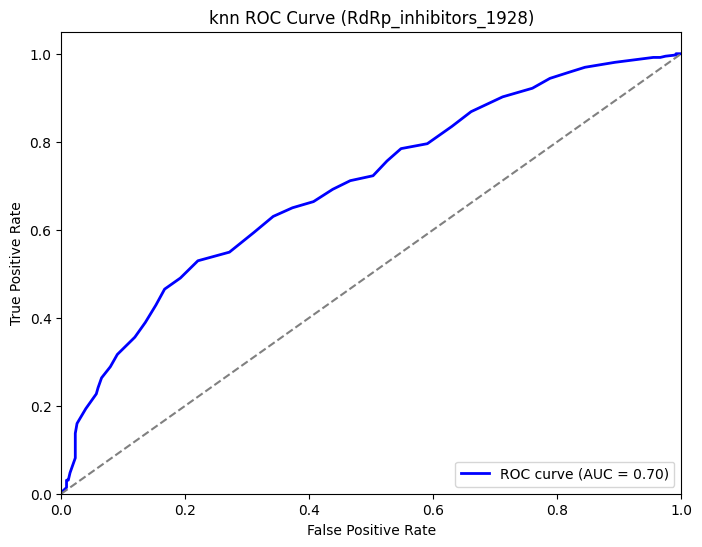

In [ ]:
y_pred_prob = knn.predict_proba(X_test)[:, 1]  # Get the probabilities for the positive class
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
roc_auc_k = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('knn ROC Curve (RdRp_inhibitors_1928)')
plt.legend(loc='lower right')
plt.show()

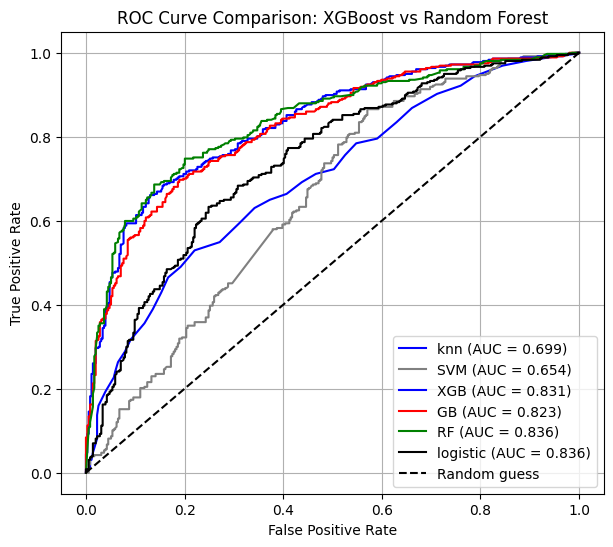

In [ ]:
y_pred_prob_knn = knn.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_prob_model = model.predict_proba(X_test)[:, 1]
y_pred_prob_xgb_clf = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_prob_clf = clf.predict_proba(X_test)[:, 1]

gb_probs = gb.predict_proba(X_test)[:, 1]

# 6. 計算 ROC 曲線
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, y_pred_prob_xgb_clf)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, y_pred_prob_clf)
fpr_model, tpr_model, _ = roc_curve(y_test, y_pred_prob_model)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

# 7. 計算 AUC
auc_XGB = auc(fpr_XGB, tpr_XGB)
auc_SVM = auc(fpr_SVM, tpr_SVM)

auc_knn = auc(fpr_knn, tpr_knn)
auc_model = auc(fpr_model, tpr_model)
auc_xgb = auc(fpr_gb, tpr_gb)
auc_rf = auc(fpr_rf, tpr_rf)

# 8. 畫圖
plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', label=f'knn (AUC = {auc_knn:.3f})')
plt.plot(fpr_SVM, tpr_SVM, color='gray', label=f'SVM (AUC = {auc_SVM:.3f})')
plt.plot(fpr_XGB, tpr_XGB, color='blue', label=f'XGB (AUC = {auc_XGB:.3f})')
plt.plot(fpr_gb, tpr_gb, color='red', label=f'GB (AUC = {auc_xgb:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', label=f'RF (AUC = {auc_rf:.3f})')
plt.plot(fpr_model, tpr_model, color='black', label=f'logistic (AUC = {auc_rf:.3f})')
# 對角線 (隨機猜測)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: XGBoost vs Random Forest')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
auc_xgb

0.741814239820222

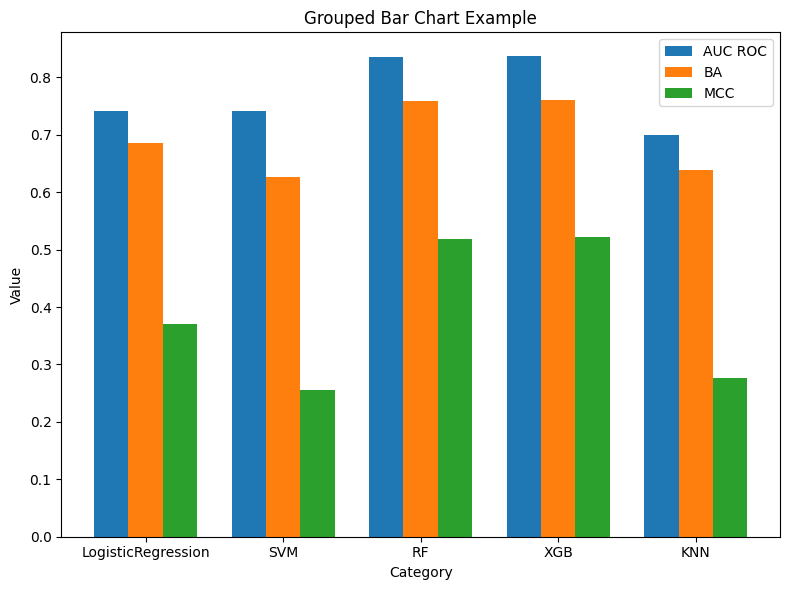

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 五個主要類別（X軸）
categories = ['LogisticRegression', 'SVM', 'RF', 'XGB', 'KNN']

# 三組資料（每組對應不同顏色的職方圖）
group1 = [auc_l, auc_s, auc_rf, roc_auc_xgb, roc_auc_k]
group2 = [BA_l, BA_s, BA_rf, BA_XGB, BA_k]
group3 = [mcc_l, mcc_s, mcc_rf, mcc_XGB, mcc_k]

x = np.arange(len(categories))  # X 軸座標
width = 0.25                    # 每個柱子的寬度

# 畫圖
plt.figure(figsize=(8, 6))
plt.bar(x - width, group1, width, label='AUC ROC')
plt.bar(x, group2, width, label='BA')
plt.bar(x + width, group3, width, label='MCC')

# X 軸標籤
plt.xticks(x, categories)

# 加標題與圖例
plt.title('Grouped Bar Chart Example')
plt.xlabel('Category')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 這是DENV inhibitors RdRp_登革熱


import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import re
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import shap
data=pd.read_csv('/content/GNN/資料集.csv')
data=data.iloc[1:,:]
data=data[~data['Unnamed: 2'].isnull()]
data=data[~data['Unnamed: 1'].isnull()]
data=data.iloc[:-1,:]
data['Unnamed: 2']=data['Unnamed: 2'].astype("float")

data=data[data['Unnamed: 2']<1000000]
desc_names = [
    'MolWt', 'HeavyAtomCount', 'NumAtoms', 'NumRings', 'NumAromaticRings', 'FractionCSP3',
    'MolLogP', 'TPSA', 'LabuteASA',
    'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds',
    'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Chi0v', 'Chi1v',
    'PEOE_VSA1', 'PEOE_VSA9', 'EState_VSA3'
]


data['Standard']=data['Unnamed: 2']
data['Standard1']=data['Standard'].apply(lambda x:0 if x>=10000 else 1)



In [ ]:
data1=data[data['Standard1']==1]
data1

,DENV inhibitors RdRp_登革熱病毒抑制物_3738,Unnamed: 1,Unnamed: 2,Unnamed: 3,Standard,Standard1
1,CHEMBL1631360,CC1(C)CC(Nc2nc(-c3ccc(-c4ccc(Cl)cc4)s3)c3ccccc...,40.0,NaN,40.0,1
2,CHEMBL1631362,O=C(CCCC[C@@H]1SC[C@H]2NC(=O)N[C@@H]12)NCCOCCO...,234.0,NaN,234.0,1
3,CHEMBL1652119,Cc1ccc(C)c(OCCCCCCN2C[C@H](O)[C@@H](O)[C@H](O)...,100.0,NaN,100.0,1
4,CHEMBL1630219,C#C[C@@]1(O)[C@H](O)[C@@H](CO)O[C@H]1n1cc(C(N)...,6990.0,NaN,6990.0,1
5,CHEMBL1630220,C#C[C@@]1(O)[C@H](OC(=O)C(C)C)[C@@H](COC(=O)C(...,540.0,NaN,540.0,1
...,...,...,...,...,...,...
3733,CHEMBL4441561,N#C/C(=C\c1ccc(-c2ccc(C(=O)O)cc2)s1)c1nc2cc(Cl...,5950.0,NaN,5950.0,1
3734,CHEMBL7301,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)Nc2ccc(O)cc2...,1000.0,NaN,1000.0,1
3735,CHEMBL54440,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1820.0,NaN,1820.0,1
3736,CHEMBL4463936,C#Cc1c(C#N)ncn1[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,550.0,NaN,550.0,1


In [ ]:
from collections import Counter
strings=list(data1['Unnamed: 1'][:])
def extract_substrings(s, min_length=2):
    substrings = []
    for length in range(min_length, len(s) + 1):  # 從最小長度到字串的最大長度
        for i in range(len(s) - length + 1):  # 提取每個子串
            substrings.append(s[i:i+length])
    return substrings

# 提取所有字串中的子串
all_substrings = []
for s in strings:
    all_substrings.extend(extract_substrings(s))

# 統計子串出現次數
substring_counts = Counter(all_substrings)

# 找出出現次數最多的子串
most_common_substrings = substring_counts.most_common(10)  # 找出前10個最常出現的子串

# 輸出結果
print("最常出現的子串:")
for substring, count in most_common_substrings:
    print(f"子串: {substring}, 出現次數: {count}")

最常出現的子串:
子串: cc, 出現次數: 11401
子串: ccc, 出現次數: 5628
子串: )c, 出現次數: 4380
子串: O), 出現次數: 4312
子串: c2, 出現次數: 3703
子串: c1, 出現次數: 3637
子串: c(, 出現次數: 3569
子串: C(, 出現次數: 3532
子串: CC, 出現次數: 3279
子串: (C, 出現次數: 3051


In [ ]:
from rdkit import Chem
from sklearn.decomposition import PCA
from sklearn.metrics import matthews_corrcoef
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.QED import qed
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import re
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import shap
data=pd.read_csv('/content/GNN/資料集.csv')
data=data.iloc[1:,:]
data=data[~data['Unnamed: 2'].isnull()]
data=data[~data['Unnamed: 1'].isnull()]
data=data.iloc[:-1,:]
data['Unnamed: 2']=data['Unnamed: 2'].astype("float")

data=data[data['Unnamed: 2']<1000000]
data['Standard']=data['Unnamed: 2']
data['Standard1']=data['Standard'].apply(lambda x:0 if x>=10000 else 1)

In [ ]:
data['Standard1'].value_counts()

,count
Standard1,
0,1818
1,1735


In [ ]:
temp=pd.DataFrame({"DENV inhibitors RdRp_登革熱病毒抑制物_3738":[''],'Unnamed: 1':['C1=CC(=C(C=C1OC2=C(C=C(C=C2I)CC(=O)O)I)I)O'],'Unnamed: 2':[4.09],'Unnamed: 3':[''],'Standard':[4.09],'Standard1':[1]})
data=pd.concat([data,temp])

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

smiles_series = data["Unnamed: 1"]

fingerprints = []
valid_index = []

for idx, smiles in smiles_series.items():
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        # 有些 SMILES 可能 parse 失敗，直接跳過
        continue

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,      # ECFP4
        nBits=1024
    )

    fingerprints.append(list(fp))
    valid_index.append(idx)

# 建立 fingerprint DataFrame
fp_df = pd.DataFrame(
    fingerprints,
    columns=[f"FP_{i}" for i in range(1024)],
    index=valid_index
)

print(fp_df.shape)
fp_df.head()

[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerator
[08:33:52] DEPRECATION WARNING: please use MorganGenerat

(3554, 1024)


,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_1014,FP_1015,FP_1016,FP_1017,FP_1018,FP_1019,FP_1020,FP_1021,FP_1022,FP_1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(fp_df.iloc[:,:])


KeyboardInterrupt: 

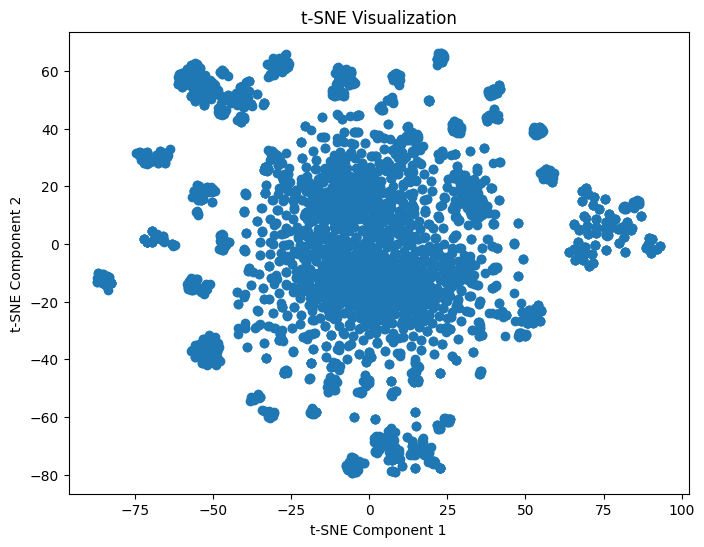

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1],  cmap='viridis')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.show()



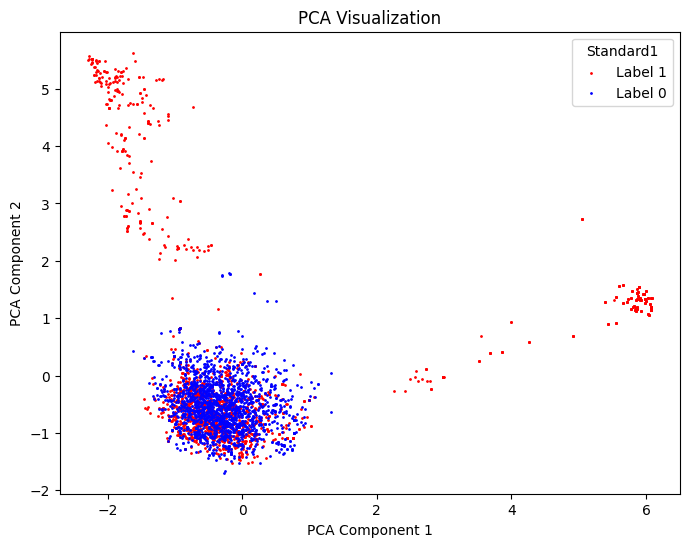

In [ ]:

pca = PCA(n_components=2)
X_PCA = pca.fit_transform(fp_df)

# 繪製 PCA 圖
import numpy as np
df = pd.DataFrame({'Standard1': list(data['Standard1']),'DENV inhibitors RdRp_登革熱病毒抑制物_3738':list(data['DENV inhibitors RdRp_登革熱病毒抑制物_3738']),'chemical':list(data['Unnamed: 1'])})
df1 = pd.DataFrame(
    X_PCA,
    columns=['a', 'b']
)
data1=pd.concat([df1,df], axis=1)
data1.to_csv("登革熱.csv",encoding='big5',index=False)

# 特殊

data1=data1[~((data1['b']>2)&(data1['Standard1']==0))]

labels = data1['Standard1'].unique()
colors = ['red', 'blue']

plt.figure(figsize=(8, 6))

for label, color in zip(labels, colors):
    idx = data1['Standard1'] == label
    plt.scatter(
        data1.loc[idx, 'a'],
        data1.loc[idx, 'b'],
        c=color,
        label=f'Label {label}',
        s=1
    )

plt.legend(title='Standard1')
plt.title('PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [ ]:
data

,DENV inhibitors RdRp_登革熱病毒抑制物_3738,Unnamed: 1,Unnamed: 2,Unnamed: 3,Standard,Standard1
1,CHEMBL1631360,CC1(C)CC(Nc2nc(-c3ccc(-c4ccc(Cl)cc4)s3)c3ccccc...,40.00,NaN,40.00,1
2,CHEMBL1631362,O=C(CCCC[C@@H]1SC[C@H]2NC(=O)N[C@@H]12)NCCOCCO...,234.00,NaN,234.00,1
3,CHEMBL1652119,Cc1ccc(C)c(OCCCCCCN2C[C@H](O)[C@@H](O)[C@H](O)...,100.00,NaN,100.00,1
4,CHEMBL1630219,C#C[C@@]1(O)[C@H](O)[C@@H](CO)O[C@H]1n1cc(C(N)...,6990.00,NaN,6990.00,1
5,CHEMBL1630220,C#C[C@@]1(O)[C@H](OC(=O)C(C)C)[C@@H](COC(=O)C(...,540.00,NaN,540.00,1
...,...,...,...,...,...,...
3734,CHEMBL7301,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)Nc2ccc(O)cc2...,1000.00,NaN,1000.00,1
3735,CHEMBL54440,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1820.00,NaN,1820.00,1
3736,CHEMBL4463936,C#Cc1c(C#N)ncn1[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,550.00,NaN,550.00,1
3737,CHEMBL506569,CC(=O)O[C@H]1C[C@H](O[C@H]2[C@@H](O)C[C@H](O[C...,500.00,NaN,500.00,1


In [ ]:
data1

,a,b,Standard1
0,0.371813,-0.924236,1.0
1,-0.318881,0.489384,1.0
2,-0.291894,-0.492028,1.0
3,-0.054399,-0.891976,1.0
4,0.024481,-0.267375,1.0
...,...,...,...
3549,-0.526567,-0.622142,1.0
3550,0.081627,-0.065049,1.0
3551,-0.219460,-1.463945,1.0
3552,0.299477,-0.504156,1.0


In [ ]:
data1=pd.concat([df1,data2['Standard1']], axis=1)

KeyError: 'Standard1'

In [ ]:
data1

,a,b,c,Standard1
0,0.371813,-0.924233,0.090427,1.0
1,-0.318880,0.489392,0.088129,1.0
2,-0.291893,-0.492010,1.390103,1.0
3,-0.054401,-0.891995,3.545501,1.0
4,0.024479,-0.267404,2.661151,1.0
...,...,...,...,...
3549,-0.526566,-0.622148,-0.315276,1.0
3550,0.081627,-0.065056,1.552437,1.0
3551,-0.219460,-1.463933,3.017288,1.0
3552,0.299479,-0.504147,2.449194,1.0


/tmp/ipython-input-511693676.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data1['Standard1'][3553]=1


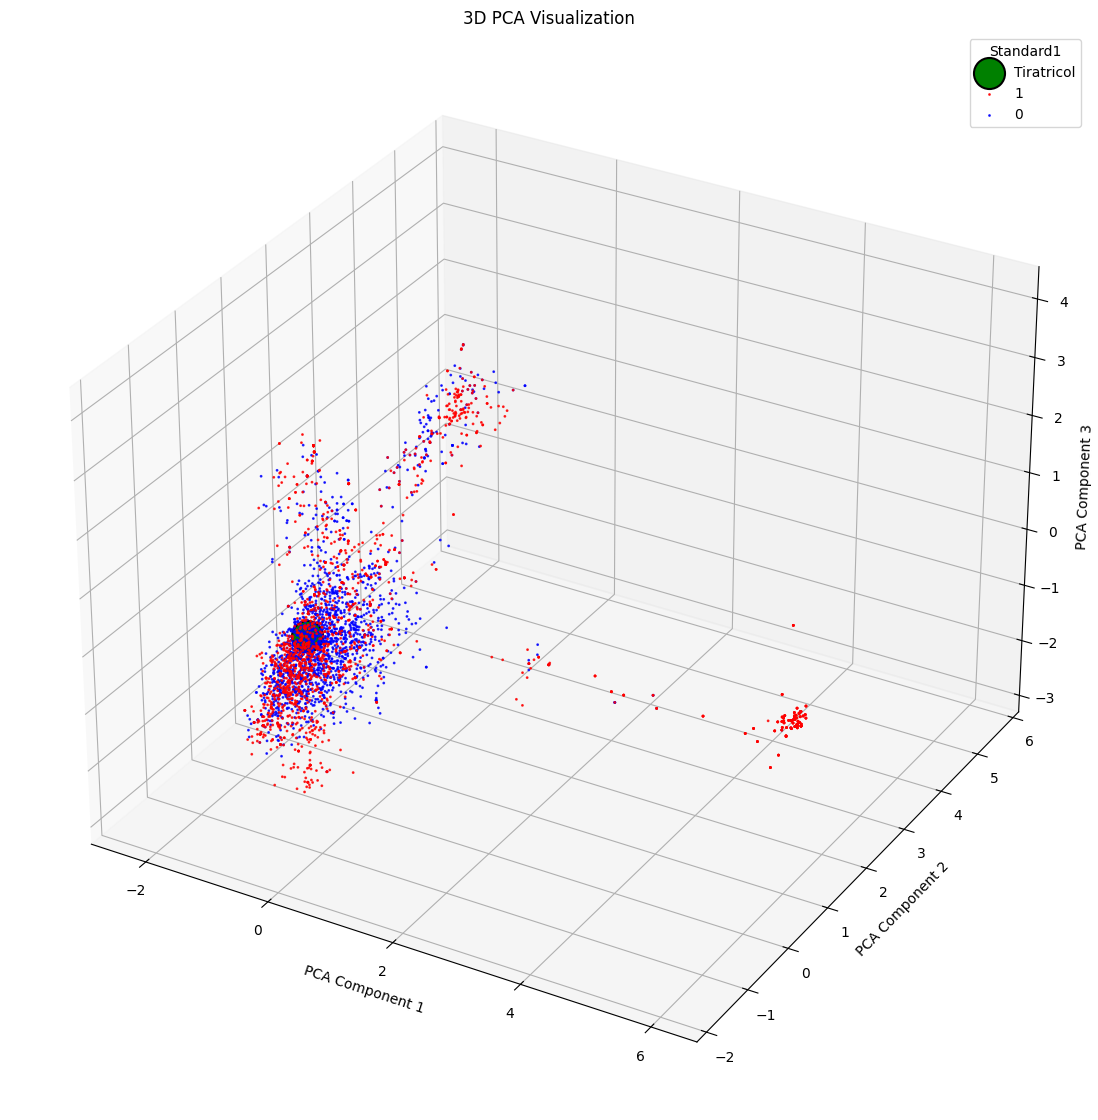

In [ ]:
pca = PCA(n_components=3)
X_PCA = pca.fit_transform(fp_df)
df1 = pd.DataFrame(
    X_PCA,
    columns=['a', 'b','c']
)
data2=data.reset_index()
data1=pd.concat([df1,data2['Standard1']], axis=1)
data1.to_csv("登革熱.csv",encoding='big5',index=False)
fig = plt.figure(figsize=(16, 14))
ax = fig.add_subplot(111, projection='3d')
data1['Standard1'][3553]=1
labels = data1['Standard1'].unique()
colors = plt.cm.tab10(range(len(labels)))
point_3553 = data1.loc[3553]

ax.scatter(
    point_3553['a'],
    point_3553['b'],
    point_3553['c'],
    color='green',      # 特別顏色（可改）
    s=500,            # 大顆
    edgecolors='black',
    linewidth=1.5,
    label='Tiratricol'
)
color_map = {
    1.0: 'red',
    0.0: 'blue'
}
for label, color in color_map.items():
    subset = data1[data1['Standard1'] == label]
    ax.scatter(
        subset['a'],
        subset['b'],
        subset['c'],
        color=color,
        label=str(label)[0],
        s=1,
        alpha=0.8
    )

ax.set_title('3D PCA Visualization')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

ax.legend(title='Standard1')
plt.show()

/tmp/ipython-input-3415621315.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data1['Standard1'][3553]=1


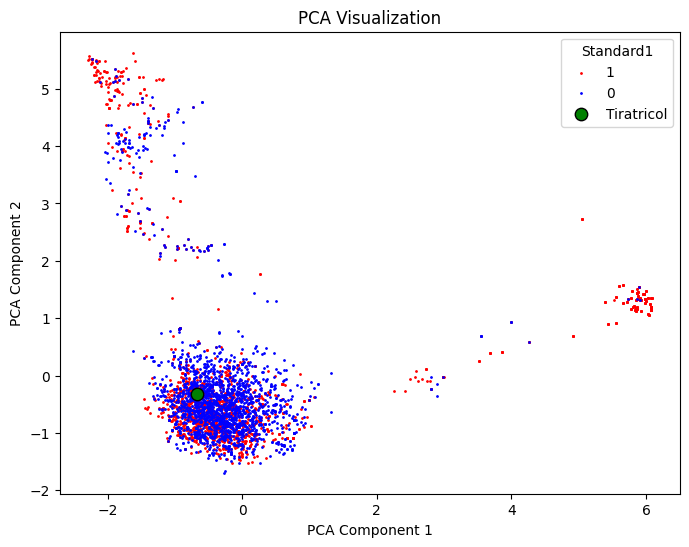

In [ ]:
pca = PCA(n_components=2)
X_PCA = pca.fit_transform(fp_df)
df1 = pd.DataFrame(
    X_PCA,
    columns=['a', 'b']
)
data2=data.reset_index()
data1=pd.concat([df1,data2['Standard1']], axis=1)
data1.to_csv("登革熱.csv",encoding='big5',index=False)

data1['Standard1'][3553]=1
labels = data1['Standard1'].unique()
colors = plt.cm.tab10(range(len(labels)))
point_3553 = data1.loc[3553]

labels = data1['Standard1'].unique()
colors = ['red', 'blue']

plt.figure(figsize=(8, 6))

for label, color in zip(labels, colors):
    idx = data1['Standard1'] == label
    plt.scatter(
        data1.loc[idx, 'a'],
        data1.loc[idx, 'b'],
        c=color,
        label=f'{str(label)[0]}',
        s=1
    )
x_3553 = point_3553['a']
y_3553 = point_3553['b']

# 畫紅色點（放大）
plt.scatter(
    x_3553,
    y_3553,
    c='green',
    s=80,
    edgecolors='black',
    zorder=5,
    label='Tiratricol'
)
plt.legend(title='Standard1')
plt.title('PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()
